# Grindworld mit Q-Learning / SARSA

In [1]:
import random 
import numpy as np
import matplotlib.pyplot as plt

# Setup
epsilon = 0.2 # Exploration rate
learning_rate = 0.1
discount_factor = 0.9
goal_state = (0, 5) # Süd westlichstes Feld 

w, h = 6,6 # width and height of the grid
actions = [0,1,2,3,4] # 1: nord, 2: sud, 3: west, 4: ost, 5: tunnel
states = [(n, m) for m in range(h) for n in range(w)] # n --> row, m --> column
q_table = np.zeros((len(states),len(actions)))

In [ ]:
# Functions
def state_index(state):
    return states.index(state)

def step(state, action):
    x, y = state
    
    if state == goal_state:
        return state, 0
    if action == 0:  # nord (y - 1)
        y = max(0, y - 1)
        reward = -1
    elif action == 1:  # süd (y + 1)
        y = min(h - 1, y + 1)
        reward = -1
    elif action == 2:  # west (x - 1)
        x = max(0, x - 1)
        reward = -1
    elif action == 3:  # ost (x + 1)
        x = min(w - 1, x + 1)
        reward = -1
        
    elif action == 4:  # tunnel
        if y == 0:  # nur wenn in oberster Zeile
            y = h - 1
        reward = -2
        
    new_state = (x, y)
    
    # Endzustand: südwestliche Ecke = (0, h-1)
    # if new_state == (0, h - 1):
    #     reward = 0

    return new_state, reward

def get_policy(q_table):
    policy = []
    for s in range(len(states)):
        best_action = np.argmax(q_table[s])
        policy.append(best_action)
    return policy

def render_policy(policy):
    action_symbols = {0: '↑', 1: '↓', 2: '←', 3: '→', 4: 'T'}
    grid = [['' for _ in range(w)] for _ in range(h)]
    
    for idx, action in enumerate(policy):
        n, m = states[idx]
        if (n, m) == (0, h - 1):  # Zielzustand
            grid[m][n] = 'G'
        else:
            grid[m][n] = action_symbols[action]
    
    for row in grid:  # Zeige von oben nach unten
        print(' '.join(row))

def plot_action_values(q_table):
    values = np.zeros((h, w))
    for idx, state in enumerate(states):
        x, y = state
        values[y][x] = np.max(q_table[idx])  # bester Q-Wert pro Zustand
    
    values = np.flipud(values)
    
    fig, ax = plt.subplots()
    im = ax.imshow(values, cmap='Reds', origin='lower')  # wichtig: origin='lower' für (0,0) unten links
    
    for y in range(h):
        for x in range(w):
            text = ax.text(x, y, f"{values[y][x]:.1f}", ha="center", va="center", color="black")
    
    ax.set_title("Action-Value Function (max Q)")
    plt.colorbar(im)
    plt.show()

In [7]:
# Training the Q-learning agent
for episode in range(1000):
    state = random.choice(states)
    for step_count in range(100):
        if random.uniform(0 , 1) < epsilon: # random action
            action = random.choice(actions)
        else: # greedy action
            action = np.argmax(q_table[state_index(state)])
        
        next_state, reward = step(state, action) # take Action, receive next state and reward
        
        old_q = q_table[state_index(state), action ]
        next_max = np.max(q_table[state_index(next_state)])
        new_q = old_q + learning_rate*(reward + discount_factor * next_max - old_q)
        q_table[state_index(state), action] = new_q
        state = next_state
        
        if next_state == goal_state:
            break

In [4]:
# Train the SARSA agent
for episode in range(1000):
    state = random.choice(states)

    # choose initial action (SARSA starts with (s, a))
    if random.uniform(0, 1) < epsilon:
        action = random.choice(actions)
    else:
        action = np.argmax(q_table[state_index(state)])

    for step_count in range(100):
        next_state, reward = step(state, action)

        # epsilon-greedy next action (on-policy)
        if random.uniform(0, 1) < epsilon:
            next_action = random.choice(actions)
        else:
            next_action = np.argmax(q_table[state_index(next_state)])

        # SARSA update
        old_q = q_table[state_index(state), action]
        next_q = q_table[state_index(next_state), next_action]
        new_q = old_q + learning_rate * (reward + discount_factor * next_q - old_q)
        q_table[state_index(state), action] = new_q

        if next_state == (0, h - 1):  # goal
            break

        state = next_state
        action = next_action


In [ ]:
policy = get_policy(q_table)
render_policy(policy)

T ← ← ← ← ←
↓ ← ← ← ← ↑
↓ ↑ ↓ ← ← →
↓ ← ← ↓ ↓ ←
↓ ↓ ↓ ← ↓ ←
G ← ← ← ← ←


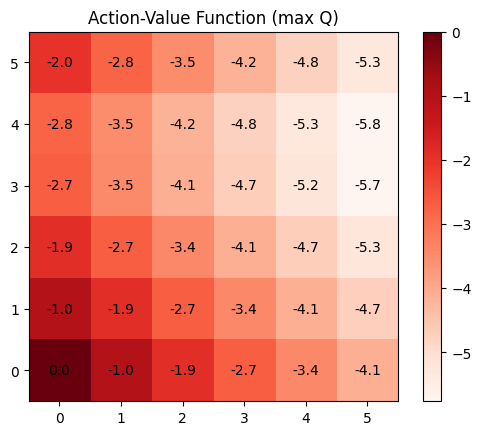

In [8]:
plot_action_values(q_table)